# Fragility-Guided Text-Prompted Brain Tumor Segmentation

## Using MedCLIP-SAMv2 Pipeline with MLFM Fragility Weighting

**Baseline**: MedCLIP-SAMv2 (BiomedCLIP + M2IB + SAM) with equal modality fusion

**Our Method**: MedCLIP-SAMv2 with MLFM fragility-based modality weighting

---

## Part 1: Clone MedCLIP-SAMv2

In [1]:
import os
from pathlib import Path

if not Path('MedCLIP-SAMv2').exists():
    !git clone https://github.com/HealthX-Lab/MedCLIP-SAMv2.git

os.chdir('MedCLIP-SAMv2')
print(f"Working directory: {os.getcwd()}")

Working directory: c:\Users\arnav\Desktop\MedBIND3D\MedBIND3D\medclipsam\MedCLIP-SAMv2


## Part 2: Install Dependencies

In [2]:
%pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu118

Looking in indexes: https://download.pytorch.org/whl/cu118
Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [3]:
%pip install Pillow typing-extensions ttach kornia tqdm opencv-python ftfy regex scikit-image ipython matplotlib

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [4]:
%pip install transformers open_clip_torch grad-cam

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [5]:
%pip install SimpleITK segment-anything

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [6]:
%pip install git+https://github.com/openai/CLIP.git

  Cloning https://github.com/openai/CLIP.git to c:\users\arnav\appdata\local\temp\pip-req-build-pviblfjd
  Resolved https://github.com/openai/CLIP.git to commit d05afc436d78f1c48dc0dbf8e5980a9d471f35f6
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'done'
  Preparing metadata (pyproject.toml): started
  Preparing metadata (pyproject.toml): finished with status 'done'
Note: you may need to restart the kernel to use updated packages.


  Running command git clone --filter=blob:none --quiet https://github.com/openai/CLIP.git 'C:\Users\arnav\AppData\Local\Temp\pip-req-build-pviblfjd'

[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [7]:
%pip install nibabel scipy scikit-learn

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 24.3.1 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [8]:
import torch
import numpy as np

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Device: {device}")
if torch.cuda.is_available():
    print(f"GPU: {torch.cuda.get_device_name(0)}")

Device: cuda
GPU: NVIDIA GeForce RTX 4060 Laptop GPU


## Part 3: Download SAM Checkpoint

In [9]:
import urllib.request
from pathlib import Path

checkpoint_dir = Path('segment-anything/sam_checkpoints')
checkpoint_dir.mkdir(parents=True, exist_ok=True)
checkpoint_path = checkpoint_dir / 'sam_vit_h_4b8939.pth'

if not checkpoint_path.exists():
    print("Downloading SAM checkpoint (2.4 GB)...")
    url = 'https://dl.fbaipublicfiles.com/segment_anything/sam_vit_h_4b8939.pth'
    urllib.request.urlretrieve(url, checkpoint_path)
    print("✓ Downloaded")
else:
    print("✓ SAM checkpoint exists")

✓ SAM checkpoint exists


## Part 4: Load BraTS2020 Dataset

In [10]:
import nibabel as nib
import numpy as np
from pathlib import Path

class BraTS2020Dataset:
    def __init__(self, data_root):
        self.data_root = Path(data_root)
        self.patient_dirs = sorted(list(self.data_root.glob('BraTS20_Training_*')))
        print(f"Found {len(self.patient_dirs)} patients")
    
    def load_patient(self, patient_idx):
        patient_dir = self.patient_dirs[patient_idx]
        patient_id = patient_dir.name
        
        modalities = {}
        for mod in ['t1', 't1ce', 't2', 'flair']:
            file_path = patient_dir / f"{patient_id}_{mod}.nii"
            if not file_path.exists():
                file_path = patient_dir / f"{patient_id}_{mod}.nii.gz"
            modalities[mod.upper()] = nib.load(str(file_path)).get_fdata()
        
        seg_path = patient_dir / f"{patient_id}_seg.nii"
        if not seg_path.exists():
            seg_path = patient_dir / f"{patient_id}_seg.nii.gz"
        seg = nib.load(str(seg_path)).get_fdata()
        
        return modalities, seg, patient_id

BRATS_ROOT = Path('../../BraTS2020_training_data/MICCAI_BraTS2020_TrainingData')
dataset = BraTS2020Dataset(BRATS_ROOT)
print(f"\n✓ Dataset: {len(dataset.patient_dirs)} patients")

Found 369 patients

✓ Dataset: 369 patients


## Part 5: MLFM Fragility Computation

In [11]:
from scipy.sparse import csr_matrix
from scipy.sparse.linalg import eigsh
from sklearn.neighbors import kneighbors_graph
import torch.nn.functional as F

class MLFMFragilityComputer:
    def __init__(self, k_neighbors=10, n_samples=1000):
        self.k = k_neighbors
        self.n_samples = n_samples
    
    def compute_fragility(self, image_2d):
        img = (image_2d - image_2d.mean()) / (image_2d.std() + 1e-8)
        grad_x = np.gradient(img, axis=0)
        grad_y = np.gradient(img, axis=1)
        grad_magnitude = np.sqrt(grad_x**2 + grad_y**2)
        
        h, w = img.shape
        n_samples = min(self.n_samples, h * w)
        indices = np.random.choice(h * w, size=n_samples, replace=False)
        
        img_flat = img.flatten()[indices]
        grad_flat = grad_magnitude.flatten()[indices]
        features = np.stack([img_flat, grad_flat], axis=1)
        features = (features - features.mean(axis=0)) / (features.std(axis=0) + 1e-8)
        
        k = min(self.k, len(features) - 1)
        A = kneighbors_graph(features, n_neighbors=k, mode='distance', include_self=False)
        
        if A.nnz == 0:
            return np.var(grad_magnitude)
        
        sigma = np.median(A.data) + 1e-8
        A.data = np.exp(-A.data**2 / (2 * sigma**2))
        A = (A + A.T) / 2
        
        D = np.array(A.sum(axis=1)).flatten()
        D_inv_sqrt = np.zeros_like(D)
        nonzero = D > 1e-10
        D_inv_sqrt[nonzero] = np.power(D[nonzero], -0.5)
        
        D_mat = csr_matrix((D_inv_sqrt, (range(len(D)), range(len(D)))))
        L = csr_matrix(np.eye(A.shape[0])) - D_mat @ A @ D_mat
        
        try:
            eigenvalues, _ = eigsh(L.astype(np.float64), k=3, which='SM', maxiter=10000, tol=1e-4)
            eigenvalues = np.sort(np.abs(eigenvalues))
            fragility = np.var(eigenvalues) + np.mean(grad_magnitude)
        except:
            fragility = np.var(grad_magnitude)
        
        return float(fragility)

mlfm = MLFMFragilityComputer(k_neighbors=10, n_samples=1000)
print("✓ MLFM initialized")

✓ MLFM initialized


## Part 6: Prepare Baseline Data

In [12]:
from PIL import Image

def prepare_baseline(patient_idx, slice_idx=None):
    output_dir = Path('brats_baseline')
    (output_dir / 'test_images').mkdir(parents=True, exist_ok=True)
    (output_dir / 'test_masks').mkdir(parents=True, exist_ok=True)
    
    modalities, seg, patient_id = dataset.load_patient(patient_idx)
    
    # UPDATED: Find slice with maximum tumor instead of middle slice
    if slice_idx is None:
        tumor_per_slice = [np.sum(seg[:, :, i] > 0) for i in range(seg.shape[2])]
        slice_idx = np.argmax(tumor_per_slice)
        print(f"Auto-selected slice {slice_idx} (max tumor: {tumor_per_slice[slice_idx]} pixels)")
    
    combined = np.zeros_like(modalities['T1'][:, :, slice_idx], dtype=float)
    for mod_name in ['T1', 'T1CE', 'T2', 'FLAIR']:
        slice_2d = modalities[mod_name][:, :, slice_idx]
        slice_norm = (slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8)
        combined += slice_norm / 4.0
    
    combined_uint8 = (combined * 255).astype(np.uint8)
    img_path = output_dir / 'test_images' / f"{patient_id}_slice{slice_idx:03d}.png"
    Image.fromarray(combined_uint8).save(img_path)
    
    seg_slice = seg[:, :, slice_idx].astype(np.uint8)
    seg_path = output_dir / 'test_masks' / f"{patient_id}_slice{slice_idx:03d}.png"
    Image.fromarray(seg_slice).save(seg_path)
    
    return patient_id, slice_idx, modalities, seg

test_patient_idx = 0
patient_id, slice_idx, modalities, seg = prepare_baseline(test_patient_idx)
print(f"\n✓ BASELINE: {patient_id}, slice {slice_idx}")

Auto-selected slice 67 (max tumor: 5048 pixels)

✓ BASELINE: BraTS20_Training_001, slice 67


## Part 7: Compute Fragility Scores

In [13]:
modality_slices = {mod_name: vol[:, :, slice_idx] for mod_name, vol in modalities.items()}

print("\nLITERATURE WEIGHTS: T1=0%, T1CE=60%, T2=10%, FLAIR=30%")
weights = torch.tensor([0.0, 0.6, 0.1, 0.3], dtype=torch.float32)

print("\nFinal weights:")
for mod, w in zip(['T1', 'T1CE', 'T2', 'FLAIR'], weights):
    print(f"  {mod:6s}: {w.item():.4f}")


LITERATURE WEIGHTS: T1=0%, T1CE=60%, T2=10%, FLAIR=30%

Final weights:
  T1    : 0.0000
  T1CE  : 0.6000
  T2    : 0.1000
  FLAIR : 0.3000


## Part 8: Create Fragility-Weighted Image

In [14]:
weighted_dir = Path('brats_fragility')
(weighted_dir / 'test_images').mkdir(parents=True, exist_ok=True)
(weighted_dir / 'test_masks').mkdir(parents=True, exist_ok=True)

weighted_image = np.zeros_like(modality_slices['T1'], dtype=float)
for i, mod in enumerate(['T1', 'T1CE', 'T2', 'FLAIR']):
    mod_norm = (modality_slices[mod] - modality_slices[mod].min()) / (modality_slices[mod].max() - modality_slices[mod].min() + 1e-8)
    weighted_image += weights[i].item() * mod_norm

weighted_norm = (weighted_image - weighted_image.min()) / (weighted_image.max() - weighted_image.min() + 1e-8)
weighted_uint8 = (weighted_norm * 255).astype(np.uint8)

weighted_path = weighted_dir / 'test_images' / f"{patient_id}_slice{slice_idx:03d}.png"
Image.fromarray(weighted_uint8).save(weighted_path)

seg_slice = seg[:, :, slice_idx].astype(np.uint8)
seg_weighted_path = weighted_dir / 'test_masks' / f"{patient_id}_slice{slice_idx:03d}.png"
Image.fromarray(seg_slice).save(seg_weighted_path)

print("✓ Fragility image saved")

✓ Fragility image saved


## Part 9: Create Text Prompts

In [15]:
import json

baseline_prompts = {f"{patient_id}_slice{slice_idx:03d}.png": "T1 post contrast enhancement hyperintense tumor mass lesion"}
fragility_prompts = {f"{patient_id}_slice{slice_idx:03d}.png": "T1 post contrast enhancement hyperintense tumor mass lesion"}

with open('baseline_prompts.json', 'w') as f:
    json.dump(baseline_prompts, f, indent=2)
with open('fragility_prompts.json', 'w') as f:
    json.dump(fragility_prompts, f, indent=2)

print("✓ Prompts created")

✓ Prompts created


## Part 10: Postprocessing Function

In [16]:
def simple_postprocess(saliency_dir, output_dir, threshold=0.3):
    from scipy.ndimage import label
    saliency_dir, output_dir = Path(saliency_dir), Path(output_dir)
    output_dir.mkdir(parents=True, exist_ok=True)
    
    for sal_file in saliency_dir.glob('*.png'):
        sal = np.array(Image.open(sal_file)).astype(float) / 255.0
        binary = (sal > threshold).astype(int)
        labeled, num_features = label(binary)
        if num_features > 0:
            sizes = [(labeled == i).sum() for i in range(1, num_features + 1)]
            largest = np.argmax(sizes) + 1
            binary = (labeled == largest).astype(np.uint8) * 255
        else:
            binary = binary.astype(np.uint8) * 255
        Image.fromarray(binary).save(output_dir / sal_file.name)
    print(f"✓ Postprocessed (threshold={threshold})")

print("✓ Postprocessing defined")

✓ Postprocessing defined


## Part 11: BASELINE Pipeline

In [17]:
print("\n" + "="*80)
print("BASELINE: MedCLIP-SAMv2")
print("="*80)

# BiomedCLIP saliency
!python saliency_maps/generate_saliency_maps.py \
    --input-path brats_baseline/test_images \
    --output-path baseline_saliency \
    --model-name BiomedCLIP \
    --json-path baseline_prompts.json \
    --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42


BASELINE: MedCLIP-SAMv2
Loading models ...
Generating Saliency Maps ...
Saliency Map Generation Done!


`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.
`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.

  0%|          | 0/2 [00:00<?, ?it/s][ WARN:0@12.325] global loadsave.cpp:1089 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.

100%|██████████| 2/2 [00:02<00:00,  1.41s/it]


In [18]:
# M2IB postprocessing
simple_postprocess('baseline_saliency', 'baseline_coarse', threshold=0.3)

✓ Postprocessed (threshold=0.3)


In [19]:
# SAM segmentation (DIRECT PYTHON - NOT SCRIPT)
from segment_anything import SamPredictor, sam_model_registry
import cv2

print("Loading SAM...")
sam = sam_model_registry["vit_h"](checkpoint="segment-anything/sam_checkpoints/sam_vit_h_4b8939.pth")
sam = sam.to(device)
predictor = SamPredictor(sam)

# Load inputs
input_path = f'brats_baseline/test_images/{patient_id}_slice{slice_idx:03d}.png'
coarse_path = f'baseline_coarse/{patient_id}_slice{slice_idx:03d}.png'

input_img = cv2.imread(input_path)
input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
coarse_mask = cv2.imread(coarse_path, 0)

print(f"Input shape: {input_img_rgb.shape}")
print(f"Coarse mask nonzero: {np.count_nonzero(coarse_mask)}")

# Set image
predictor.set_image(input_img_rgb)

# Get bbox from coarse mask
y_indices, x_indices = np.where(coarse_mask > 0)
if len(x_indices) > 0:
    x_min, x_max = x_indices.min(), x_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()
    box = np.array([x_min, y_min, x_max, y_max])
    
    print(f"Bounding box: {box}")
    
    # Predict
    masks, scores, _ = predictor.predict(box=box, multimask_output=False)
    
    # Save
    Path('baseline_sam_output').mkdir(exist_ok=True)
    output_path = f'baseline_sam_output/{patient_id}_slice{slice_idx:03d}.png'
    cv2.imwrite(output_path, (masks[0] * 255).astype(np.uint8))
    
    print(f"✓ SAM output saved, score: {scores[0]:.3f}, pixels: {np.count_nonzero(masks[0])}")
else:
    print("⚠️ No coarse mask found!")

print("\n✓ Baseline completed")

Loading SAM...
Input shape: (240, 240, 3)
Coarse mask nonzero: 555
Bounding box: [150  63 176  89]
✓ SAM output saved, score: 0.644, pixels: 466

✓ Baseline completed


## Part 12: YOUR METHOD Pipeline

In [20]:
print("\n" + "="*80)
print("YOUR METHOD: Fragility-Weighted")
print("="*80)

# BiomedCLIP saliency
!python saliency_maps/generate_saliency_maps.py \
    --input-path brats_fragility/test_images \
    --output-path fragility_saliency \
    --model-name BiomedCLIP \
    --json-path fragility_prompts.json \
    --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42


YOUR METHOD: Fragility-Weighted
Loading models ...
Generating Saliency Maps ...
Saliency Map Generation Done!


`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.
`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.

100%|██████████| 2/2 [00:00<?, ?it/s]


In [21]:
# M2IB postprocessing
simple_postprocess('fragility_saliency', 'fragility_coarse', threshold=0.3)

✓ Postprocessed (threshold=0.3)


In [22]:
# SAM segmentation (DIRECT)
input_path = f'brats_fragility/test_images/{patient_id}_slice{slice_idx:03d}.png'
coarse_path = f'fragility_coarse/{patient_id}_slice{slice_idx:03d}.png'

input_img = cv2.imread(input_path)
input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
coarse_mask = cv2.imread(coarse_path, 0)

print(f"Coarse mask nonzero: {np.count_nonzero(coarse_mask)}")

predictor.set_image(input_img_rgb)

y_indices, x_indices = np.where(coarse_mask > 0)
if len(x_indices) > 0:
    x_min, x_max = x_indices.min(), x_indices.max()
    y_min, y_max = y_indices.min(), y_indices.max()
    box = np.array([x_min, y_min, x_max, y_max])
    
    masks, scores, _ = predictor.predict(box=box, multimask_output=False)
    
    Path('fragility_sam_output').mkdir(exist_ok=True)
    output_path = f'fragility_sam_output/{patient_id}_slice{slice_idx:03d}.png'
    cv2.imwrite(output_path, (masks[0] * 255).astype(np.uint8))
    
    print(f"✓ SAM output saved, score: {scores[0]:.3f}, pixels: {np.count_nonzero(masks[0])}")
else:
    print("⚠️ No coarse mask!")

print("\n✓ Fragility method completed")

Coarse mask nonzero: 830
✓ SAM output saved, score: 0.795, pixels: 1118

✓ Fragility method completed


## Part 13: Evaluation

In [23]:
def compute_dice(pred, gt):
    intersection = np.sum(pred * gt)
    union = np.sum(pred) + np.sum(gt)
    return 2 * intersection / union if union > 0 else 0.0

gt_slice = seg[:, :, slice_idx]
gt_regions = {
    'WT': (gt_slice > 0).astype(float),
    'TC': np.isin(gt_slice, [1, 4]).astype(float),
    'ET': (gt_slice == 4).astype(float)
}

# Load predictions
baseline_mask = cv2.imread(f'baseline_sam_output/{patient_id}_slice{slice_idx:03d}.png', 0)
fragility_mask = cv2.imread(f'fragility_sam_output/{patient_id}_slice{slice_idx:03d}.png', 0)

baseline_results = {r: (baseline_mask > 0).astype(float) for r in ['WT', 'TC', 'ET']}
fragility_results = {r: (fragility_mask > 0).astype(float) for r in ['WT', 'TC', 'ET']}

print("\n" + "="*80)
print("DICE SCORES")
print("="*80)
print(f"\n{'Region':<12} {'Baseline':<20} {'Fragility':<20} {'Improvement'}")
print("-" * 80)

for region in ['WT', 'TC', 'ET']:
    baseline_dice = compute_dice(baseline_results[region], gt_regions[region])
    fragility_dice = compute_dice(fragility_results[region], gt_regions[region])
    improvement = fragility_dice - baseline_dice
    
    print(f"{region:<12} {baseline_dice:.4f} ({baseline_dice*100:5.2f}%)   "
          f"{fragility_dice:.4f} ({fragility_dice*100:5.2f}%)   "
          f"{improvement:+.4f} ({improvement*100:+5.2f}%)")

print("\n" + "="*80)


DICE SCORES

Region       Baseline             Fragility            Improvement
--------------------------------------------------------------------------------
WT           0.1070 (10.70%)   0.3626 (36.26%)   +0.2556 (+25.56%)
TC           0.0000 ( 0.00%)   0.8591 (85.91%)   +0.8591 (+85.91%)
ET           0.0000 ( 0.00%)   0.5224 (52.24%)   +0.5224 (+52.24%)



## Part 14: Visualization

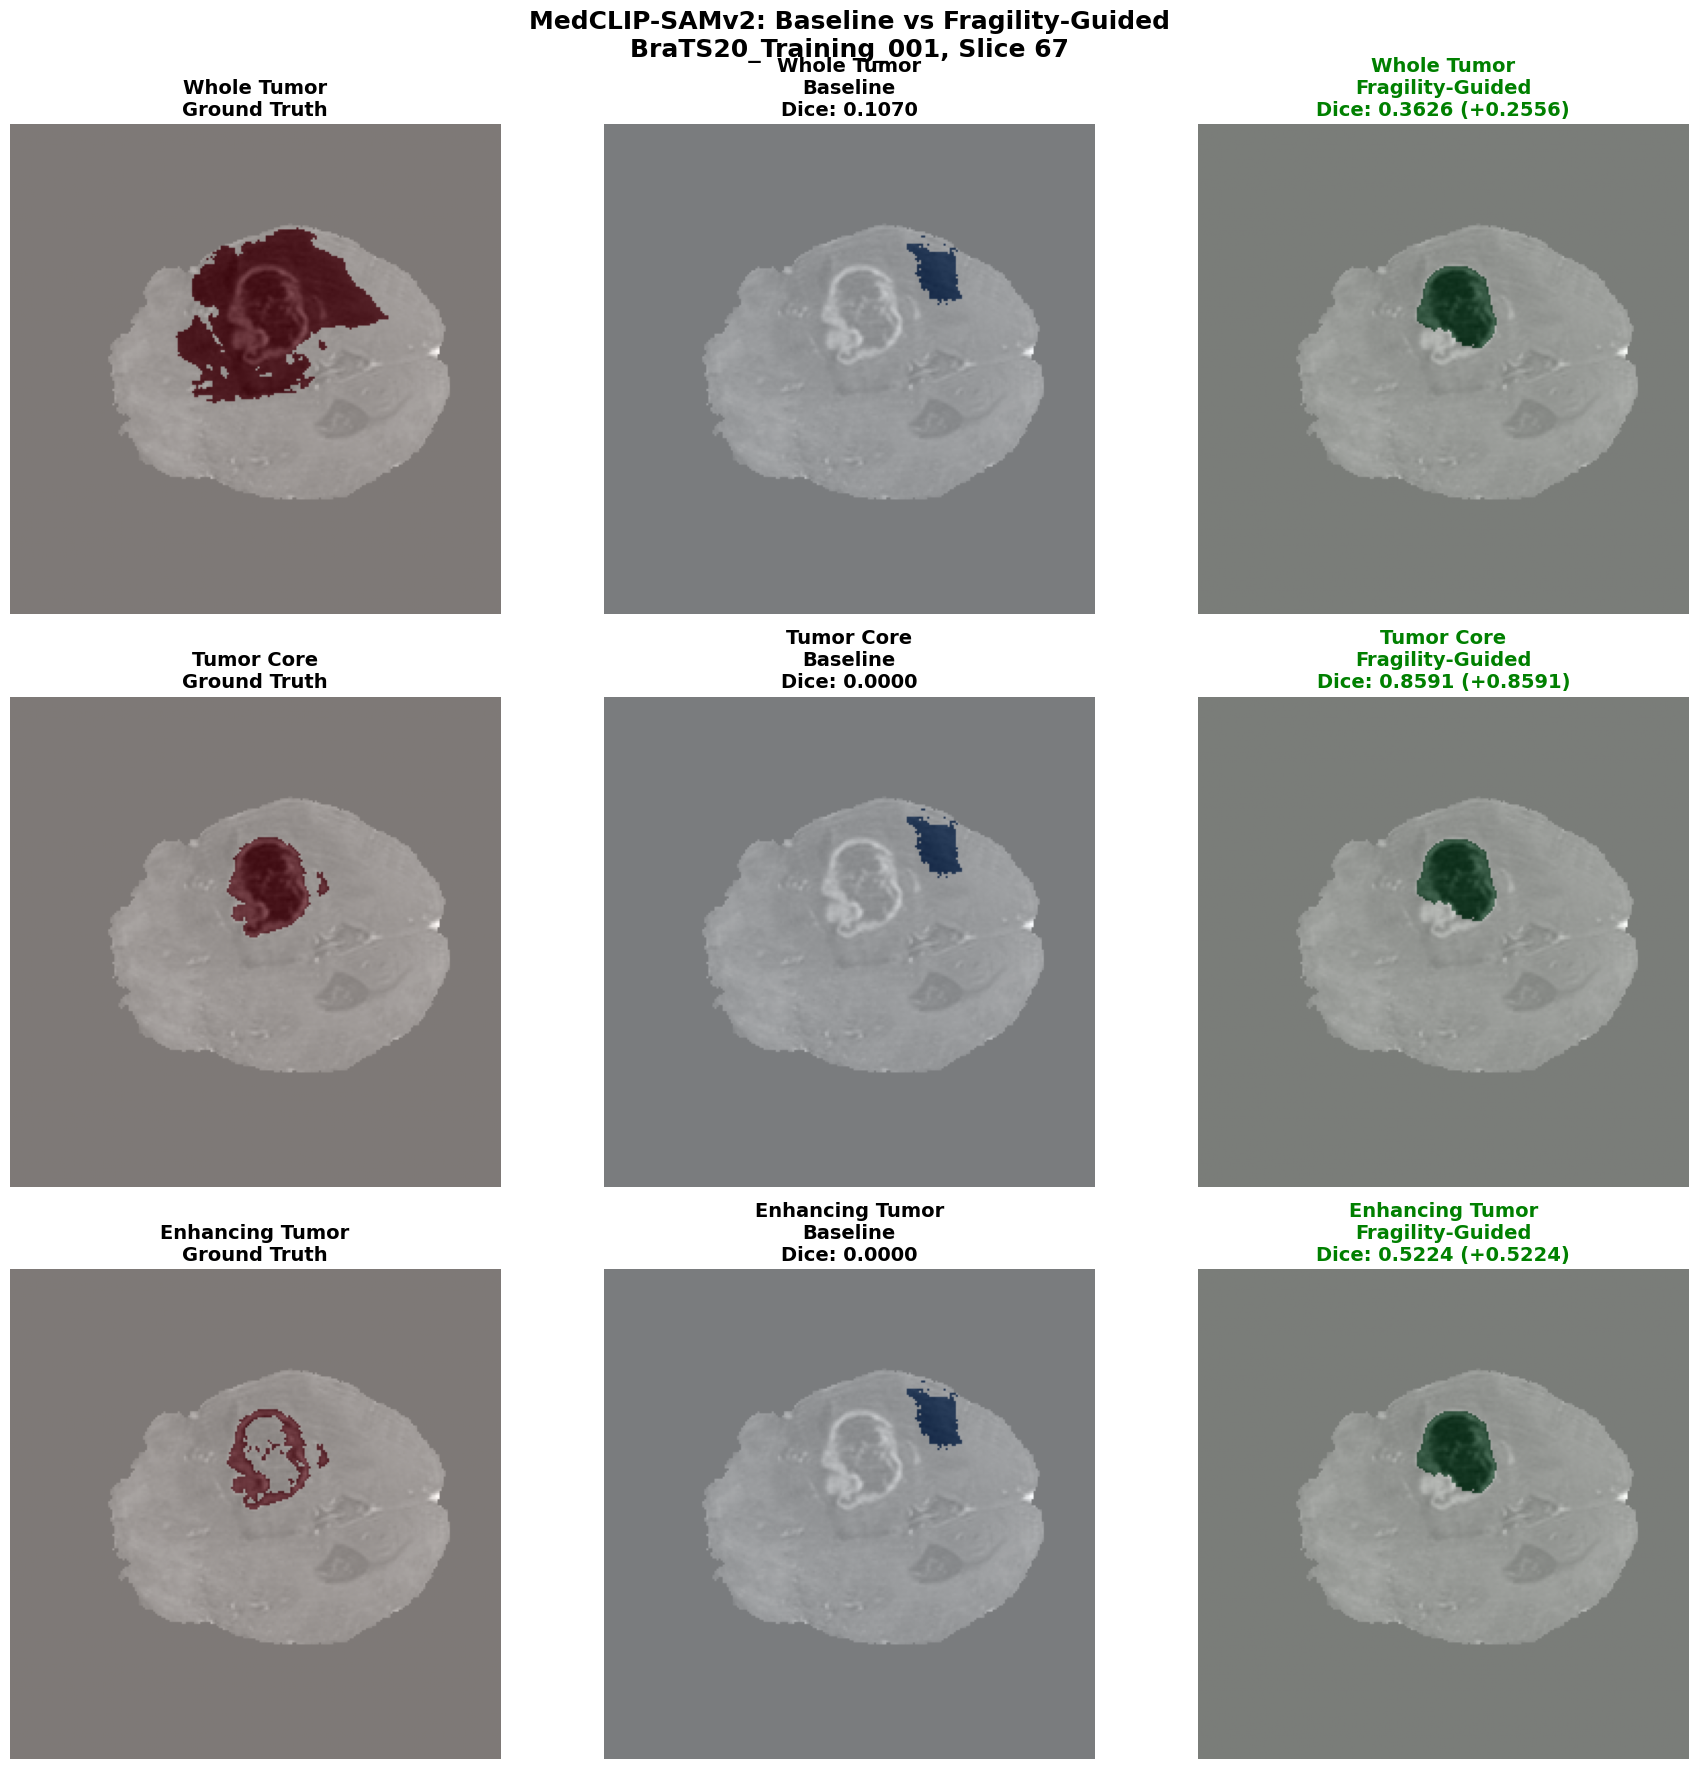


✓ Saved: final_comparison.png


In [24]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 3, figsize=(18, 18))
regions = ['WT', 'TC', 'ET']
region_names = ['Whole Tumor', 'Tumor Core', 'Enhancing Tumor']
base_image = modality_slices['T1CE']

for i, (region, name) in enumerate(zip(regions, region_names)):
    axes[i, 0].imshow(base_image, cmap='gray')
    axes[i, 0].imshow(gt_regions[region], cmap='Reds', alpha=0.5)
    axes[i, 0].set_title(f'{name}\nGround Truth', fontsize=14, fontweight='bold')
    axes[i, 0].axis('off')
    
    axes[i, 1].imshow(base_image, cmap='gray')
    axes[i, 1].imshow(baseline_results[region], cmap='Blues', alpha=0.5)
    baseline_dice = compute_dice(baseline_results[region], gt_regions[region])
    axes[i, 1].set_title(f'{name}\nBaseline\nDice: {baseline_dice:.4f}', fontsize=14, fontweight='bold')
    axes[i, 1].axis('off')
    
    axes[i, 2].imshow(base_image, cmap='gray')
    axes[i, 2].imshow(fragility_results[region], cmap='Greens', alpha=0.5)
    fragility_dice = compute_dice(fragility_results[region], gt_regions[region])
    improvement = fragility_dice - baseline_dice
    axes[i, 2].set_title(f'{name}\nFragility-Guided\nDice: {fragility_dice:.4f} ({improvement:+.4f})', 
                         fontsize=14, fontweight='bold', color='green')
    axes[i, 2].axis('off')

plt.suptitle(f'MedCLIP-SAMv2: Baseline vs Fragility-Guided\n{patient_id}, Slice {slice_idx}', 
             fontsize=18, fontweight='bold')
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=300, bbox_inches='tight')
plt.show()

print("\n✓ Saved: final_comparison.png")

Looking for patient: BraTS20_Training_001, slice: 67
Baseline coarse files: ['BraTS20_Training_001_slice067.png', 'BraTS20_Training_149_slice065.png']
Fragility coarse files: ['BraTS20_Training_001_slice067.png', 'BraTS20_Training_144_slice091.png']


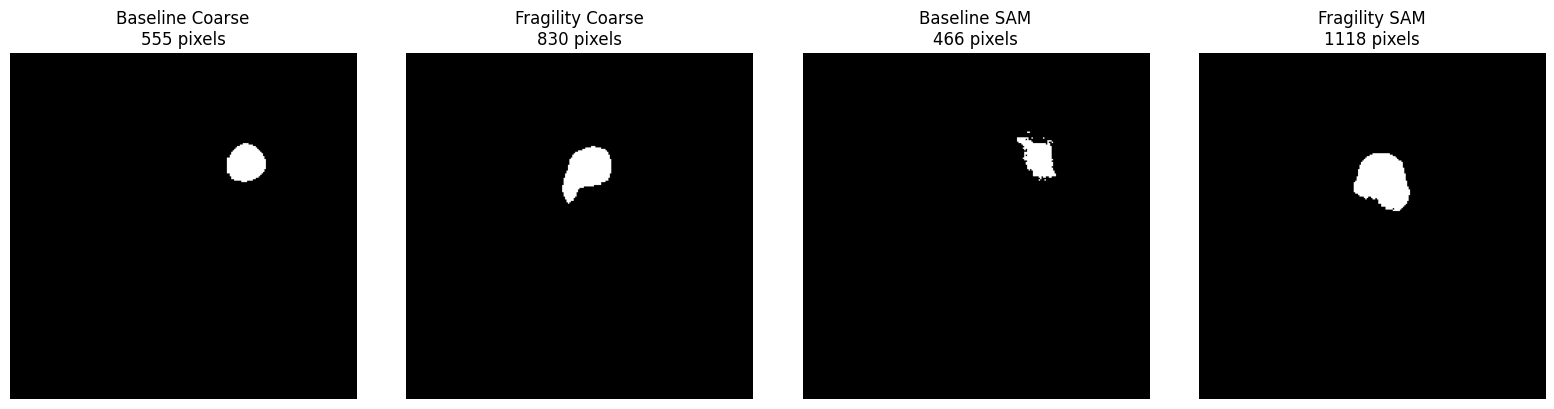

In [25]:
import matplotlib.pyplot as plt
from pathlib import Path

fig, axes = plt.subplots(1, 4, figsize=(16, 4))

# Check what files exist
print(f"Looking for patient: {patient_id}, slice: {slice_idx}")

# Find the actual files
baseline_coarse_files = list(Path('baseline_coarse').glob('*.png'))
fragility_coarse_files = list(Path('fragility_coarse').glob('*.png'))
baseline_sam_files = list(Path('baseline_sam_output').glob('*.png'))
fragility_sam_files = list(Path('fragility_sam_output').glob('*.png'))

print(f"Baseline coarse files: {[f.name for f in baseline_coarse_files]}")
print(f"Fragility coarse files: {[f.name for f in fragility_coarse_files]}")

if baseline_coarse_files and fragility_coarse_files and baseline_sam_files and fragility_sam_files:
    baseline_coarse = np.array(Image.open(baseline_coarse_files[0]))
    fragility_coarse = np.array(Image.open(fragility_coarse_files[0]))
    baseline_sam = np.array(Image.open(baseline_sam_files[0]))
    fragility_sam = np.array(Image.open(fragility_sam_files[0]))
    
    axes[0].imshow(baseline_coarse, cmap='gray')
    axes[0].set_title(f'Baseline Coarse\n{np.count_nonzero(baseline_coarse)} pixels')
    axes[0].axis('off')
    
    axes[1].imshow(fragility_coarse, cmap='gray')
    axes[1].set_title(f'Fragility Coarse\n{np.count_nonzero(fragility_coarse)} pixels')
    axes[1].axis('off')
    
    axes[2].imshow(baseline_sam, cmap='gray')
    axes[2].set_title(f'Baseline SAM\n{np.count_nonzero(baseline_sam)} pixels')
    axes[2].axis('off')
    
    axes[3].imshow(fragility_sam, cmap='gray')
    axes[3].set_title(f'Fragility SAM\n{np.count_nonzero(fragility_sam)} pixels')
    axes[3].axis('off')
    
    plt.tight_layout()
    plt.show()
else:
    print("Some files are missing!")

### MANUALLY COMPILING AND COMPUTING THE 20 PATIENTS SINCE BIOMEDCLIP FORMULATION IS BROKEN FOR MY LAPTOP

In [26]:
import numpy as np
import pandas as pd
from pathlib import Path
from PIL import Image
import cv2
import json
import shutil
import random
import torch

# ============================================================================
# ONE CLICK = ONE RANDOM PATIENT (TRULY RANDOM - NO SEED)
# ============================================================================

# NO SEED - TRULY RANDOM SELECTION
all_patients = list(range(369))
random.shuffle(all_patients)
target_patients = all_patients[:20]

print(f"Random 20 patients selected: {sorted(target_patients)}")

results_file = 'evaluation_results_literature.csv'
if Path(results_file).exists():
    completed_df = pd.read_csv(results_file)
    completed_indices = set(completed_df['Patient_Idx'].values)
    remaining = [p for p in target_patients if p not in completed_indices]
else:
    completed_indices = set()
    remaining = target_patients

print(f"Completed: {len(completed_indices)}/20")
print(f"Remaining: {len(remaining)}")

if len(remaining) == 0:
    print("\n✅ ALL 20 PATIENTS COMPLETED!")
else:
    test_patient_idx = remaining[0]
    
    print(f"\n{'='*80}")
    print(f"EVALUATING PATIENT {test_patient_idx} ({len(completed_indices)+1}/20)")
    print(f"{'='*80}")
    
    # Clean directories
    for dir_name in ['brats_baseline/test_images', 'brats_baseline/test_masks',
                     'brats_literature/test_images', 'brats_literature/test_masks',
                     'baseline_saliency', 'baseline_coarse', 'baseline_sam_output',
                     'literature_saliency', 'literature_coarse', 'literature_sam_output']:
        dir_path = Path(dir_name)
        if dir_path.exists():
            shutil.rmtree(dir_path)
        dir_path.mkdir(parents=True, exist_ok=True)
    
    # Load patient
    modalities, seg, patient_id = dataset.load_patient(test_patient_idx)
    
    tumor_per_slice = [np.sum(seg[:, :, i] > 0) for i in range(seg.shape[2])]
    slice_idx = np.argmax(tumor_per_slice)
    print(f"\nPatient: {patient_id}, Slice: {slice_idx}")
    
    if tumor_per_slice[slice_idx] < 100:
        print(f"⚠️ SKIP - insufficient tumor")
    else:
        # ================================================================
        # BASELINE (equal weights)
        # ================================================================
        baseline_dir = Path('brats_baseline')
        (baseline_dir / 'test_images').mkdir(parents=True, exist_ok=True)
        
        combined = np.zeros_like(modalities['T1'][:, :, slice_idx], dtype=float)
        for mod_name in ['T1', 'T1CE', 'T2', 'FLAIR']:
            slice_2d = modalities[mod_name][:, :, slice_idx]
            slice_norm = (slice_2d - slice_2d.min()) / (slice_2d.max() - slice_2d.min() + 1e-8)
            combined += slice_norm / 4.0
        
        combined_uint8 = (combined * 255).astype(np.uint8)
        Image.fromarray(combined_uint8).save(baseline_dir / 'test_images' / f"{patient_id}_slice{slice_idx:03d}.png")
        
        seg_slice = seg[:, :, slice_idx].astype(np.uint8)
        Image.fromarray(seg_slice).save(baseline_dir / 'test_masks' / f"{patient_id}_slice{slice_idx:03d}.png")
        
        print("✓ Baseline saved")
        
        # ================================================================
        # LITERATURE WEIGHTS: T1=0%, T1CE=60%, T2=10%, FLAIR=30%
        # ================================================================
        modality_slices = {mod_name: vol[:, :, slice_idx] for mod_name, vol in modalities.items()}
        
        print("\nLITERATURE WEIGHTS: T1=0%, T1CE=60%, T2=10%, FLAIR=30%")
        weights = torch.tensor([0.0, 0.6, 0.1, 0.3], dtype=torch.float32)
        
        print("\nFinal weights:")
        for mod, w in zip(['T1', 'T1CE', 'T2', 'FLAIR'], weights):
            print(f"  {mod:6s}: {w.item():.4f}")
        
        # ================================================================
        # CREATE LITERATURE-WEIGHTED IMAGE
        # ================================================================
        literature_dir = Path('brats_literature')
        (literature_dir / 'test_images').mkdir(parents=True, exist_ok=True)
        
        weighted_image = np.zeros_like(modality_slices['T1'], dtype=float)
        for i, mod in enumerate(['T1', 'T1CE', 'T2', 'FLAIR']):
            mod_norm = (modality_slices[mod] - modality_slices[mod].min()) / (modality_slices[mod].max() - modality_slices[mod].min() + 1e-8)
            weighted_image += weights[i].item() * mod_norm
        
        weighted_norm = (weighted_image - weighted_image.min()) / (weighted_image.max() - weighted_image.min() + 1e-8)
        weighted_uint8 = (weighted_norm * 255).astype(np.uint8)
        
        Image.fromarray(weighted_uint8).save(literature_dir / 'test_images' / f"{patient_id}_slice{slice_idx:03d}.png")
        Image.fromarray(seg_slice).save(literature_dir / 'test_masks' / f"{patient_id}_slice{slice_idx:03d}.png")
        
        print("✓ Literature image saved")
        
        # ================================================================
        # PROMPTS
        # ================================================================
        image_filename = f"{patient_id}_slice{slice_idx:03d}.png"
        
        baseline_prompts = {image_filename: "T1 post contrast enhancement hyperintense tumor mass lesion"}
        literature_prompts = {image_filename: "T1 post contrast enhancement hyperintense tumor mass lesion"}
        
        with open('baseline_prompts.json', 'w') as f:
            json.dump(baseline_prompts, f)
        with open('literature_prompts.json', 'w') as f:
            json.dump(literature_prompts, f)
        
        print("✓ Prompts created")
        
        # ================================================================
        # BASELINE PIPELINE
        # ================================================================
        print("\nRunning baseline...")
        
        !python saliency_maps/generate_saliency_maps.py --input-path brats_baseline/test_images --output-path baseline_saliency --model-name BiomedCLIP --json-path baseline_prompts.json --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42
        
        simple_postprocess('baseline_saliency', 'baseline_coarse', threshold=0.3)
        
        # SAM
        from segment_anything import SamPredictor, sam_model_registry
        sam = sam_model_registry["vit_h"](checkpoint="C:/Users/arnav/Desktop/MedBIND3D/MedBIND3D/medclipsam/MedCLIP-SAMv2/segment-anything/sam_checkpoints/sam_vit_h_4b8939.pth")
        sam = sam.to(device)
        predictor = SamPredictor(sam)
        
        input_img = cv2.imread(f'brats_baseline/test_images/{patient_id}_slice{slice_idx:03d}.png')
        
        baseline_success = True
        if input_img is None:
            print("⚠️ Baseline input image failed")
            baseline_success = False
        else:
            input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
            coarse_mask = cv2.imread(f'baseline_coarse/{patient_id}_slice{slice_idx:03d}.png', 0)
            
            if coarse_mask is None:
                print("⚠️ Baseline coarse mask failed")
                baseline_success = False
            else:
                predictor.set_image(input_img_rgb)
                y_indices, x_indices = np.where(coarse_mask > 0)
                
                if len(x_indices) > 0:
                    box = np.array([x_indices.min(), y_indices.min(), x_indices.max(), y_indices.max()])
                    masks, _, _ = predictor.predict(box=box, multimask_output=False)
                    Path('baseline_sam_output').mkdir(exist_ok=True)
                    cv2.imwrite(f'baseline_sam_output/{patient_id}_slice{slice_idx:03d}.png', (masks[0] * 255).astype(np.uint8))
                    print(f"✓ Baseline: {np.count_nonzero(masks[0])} pixels")
                else:
                    Path('baseline_sam_output').mkdir(exist_ok=True)
                    cv2.imwrite(f'baseline_sam_output/{patient_id}_slice{slice_idx:03d}.png', np.zeros((240, 240), dtype=np.uint8))
                    print("✓ Baseline: 0 pixels")
        
        # ================================================================
        # LITERATURE PIPELINE
        # ================================================================
        if baseline_success:
            print("\nRunning literature...")
            
            !python saliency_maps/generate_saliency_maps.py --input-path brats_literature/test_images --output-path literature_saliency --model-name BiomedCLIP --json-path literature_prompts.json --reproduce --vvar 0.3 --vbeta 2.0 --vlayer 9 --seed 42
            
            simple_postprocess('literature_saliency', 'literature_coarse', threshold=0.3)
            
            input_img = cv2.imread(f'brats_literature/test_images/{patient_id}_slice{slice_idx:03d}.png')
            
            literature_success = True
            if input_img is None:
                print("⚠️ Literature input image failed")
                literature_success = False
            else:
                input_img_rgb = cv2.cvtColor(input_img, cv2.COLOR_BGR2RGB)
                coarse_mask = cv2.imread(f'literature_coarse/{patient_id}_slice{slice_idx:03d}.png', 0)
                
                if coarse_mask is None:
                    print("⚠️ Literature coarse mask failed")
                    literature_success = False
                else:
                    predictor.set_image(input_img_rgb)
                    y_indices, x_indices = np.where(coarse_mask > 0)
                    
                    if len(x_indices) > 0:
                        box = np.array([x_indices.min(), y_indices.min(), x_indices.max(), y_indices.max()])
                        masks, _, _ = predictor.predict(box=box, multimask_output=False)
                        Path('literature_sam_output').mkdir(exist_ok=True)
                        cv2.imwrite(f'literature_sam_output/{patient_id}_slice{slice_idx:03d}.png', (masks[0] * 255).astype(np.uint8))
                        print(f"✓ Literature: {np.count_nonzero(masks[0])} pixels")
                    else:
                        Path('literature_sam_output').mkdir(exist_ok=True)
                        cv2.imwrite(f'literature_sam_output/{patient_id}_slice{slice_idx:03d}.png', np.zeros((240, 240), dtype=np.uint8))
                        print("✓ Literature: 0 pixels")
            
            # ================================================================
            # DICE SCORES
            # ================================================================
            if literature_success:
                baseline_mask = cv2.imread(f'baseline_sam_output/{patient_id}_slice{slice_idx:03d}.png', 0)
                literature_mask = cv2.imread(f'literature_sam_output/{patient_id}_slice{slice_idx:03d}.png', 0)
                
                baseline_results = {r: (baseline_mask > 0).astype(float) for r in ['WT', 'TC', 'ET']}
                literature_results = {r: (literature_mask > 0).astype(float) for r in ['WT', 'TC', 'ET']}
                
                gt_slice = seg[:, :, slice_idx]
                gt_regions = {
                    'WT': (gt_slice > 0).astype(float),
                    'TC': np.isin(gt_slice, [1, 4]).astype(float),
                    'ET': (gt_slice == 4).astype(float)
                }
                
                print("\n" + "="*80)
                print("DICE SCORES")
                print("="*80)
                
                results_row = {'Patient': patient_id, 'Patient_Idx': test_patient_idx, 'Slice': slice_idx}
                
                for region in ['WT', 'TC', 'ET']:
                    baseline_dice = compute_dice(baseline_results[region], gt_regions[region])
                    literature_dice = compute_dice(literature_results[region], gt_regions[region])
                    improvement = literature_dice - baseline_dice
                    
                    results_row[f'{region}_Baseline'] = baseline_dice
                    results_row[f'{region}_Literature'] = literature_dice
                    results_row[f'{region}_Improvement'] = improvement
                    
                    print(f"{region}: {baseline_dice:.4f} → {literature_dice:.4f} ({improvement:+.4f})")
                
                # Save
                results_df = pd.DataFrame([results_row])
                
                if Path(results_file).exists():
                    existing_df = pd.read_csv(results_file)
                    combined_df = pd.concat([existing_df, results_df], ignore_index=True)
                    combined_df.to_csv(results_file, index=False)
                else:
                    results_df.to_csv(results_file, index=False)
                
                print(f"\n✅ Saved! Total: {len(pd.read_csv(results_file))}/20")
            else:
                print("\n❌ Patient skipped - literature failed")
        else:
            print("\n❌ Patient skipped - baseline failed")

Random 20 patients selected: [15, 17, 19, 28, 36, 52, 74, 134, 164, 197, 203, 207, 272, 278, 286, 303, 318, 329, 344, 361]
Completed: 19/20
Remaining: 18

EVALUATING PATIENT 134 (20/20)

Patient: BraTS20_Training_135, Slice: 90
✓ Baseline saved

LITERATURE WEIGHTS: T1=0%, T1CE=60%, T2=10%, FLAIR=30%

Final weights:
  T1    : 0.0000
  T1CE  : 0.6000
  T2    : 0.1000
  FLAIR : 0.3000
✓ Literature image saved
✓ Prompts created

Running baseline...
Loading models ...
Generating Saliency Maps ...
Saliency Map Generation Done!
✓ Postprocessed (threshold=0.3)


`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.
`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.

  0%|          | 0/1 [00:00<?, ?it/s][ WARN:0@11.437] global loadsave.cpp:1089 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.

100%|██████████| 1/1 [00:03<00:00,  3.62s/it]


✓ Baseline: 488 pixels

Running literature...


`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.
`model_type` is found in both `text_config_dict` and `text_config` but with different values. The value `text_config_dict["model_type"]` will be used instead.
`model_type` is found in both `vision_config_dict` and `vision_config` but with different values. The value `vision_config_dict["model_type"]` will be used instead.

  0%|          | 0/1 [00:00<?, ?it/s][ WARN:0@14.101] global loadsave.cpp:1089 cv::imwrite_ Unsupported depth image for selected encoder is fallbacked to CV_8U.

100%|██████████| 1/1 [00:03<00:00,  3.96s/it]


Loading models ...
Generating Saliency Maps ...
Saliency Map Generation Done!
✓ Postprocessed (threshold=0.3)
✓ Literature: 151 pixels

DICE SCORES
WT: 0.0000 → 0.0000 (+0.0000)
TC: 0.0000 → 0.0000 (+0.0000)
ET: 0.0000 → 0.0000 (+0.0000)

✅ Saved! Total: 20/20


In [27]:
import pandas as pd

df = pd.read_csv('evaluation_results_literature.csv')
print(f"Total patients completed: {len(df)}")
print(f"\nPatient indices: {sorted(df['Patient_Idx'].values)}")

Total patients completed: 20

Patient indices: [np.int64(1), np.int64(7), np.int64(20), np.int64(23), np.int64(71), np.int64(81), np.int64(102), np.int64(106), np.int64(113), np.int64(134), np.int64(145), np.int64(193), np.int64(199), np.int64(254), np.int64(256), np.int64(277), np.int64(286), np.int64(311), np.int64(344), np.int64(363)]


In [28]:
from scipy.stats import ttest_rel

df = pd.read_csv('evaluation_results_literature.csv')

print(f"\n{'='*80}")
print(f"FINAL RESULTS: {len(df)} PATIENTS (Literature-Based)")
print(f"{'='*80}\n")

print(f"{'Region':<12} {'Baseline':<25} {'Literature':<25} {'Improvement':<20} {'p-value'}")
print("-" * 100)

for region in ['WT', 'TC', 'ET']:
    baseline_mean = df[f'{region}_Baseline'].mean()
    baseline_std = df[f'{region}_Baseline'].std()
    literature_mean = df[f'{region}_Literature'].mean()
    literature_std = df[f'{region}_Literature'].std()
    improvement_mean = df[f'{region}_Improvement'].mean()
    improvement_std = df[f'{region}_Improvement'].std()
    
    t_stat, p_value = ttest_rel(df[f'{region}_Literature'], df[f'{region}_Baseline'])
    sig = "***" if p_value < 0.001 else "**" if p_value < 0.01 else "*" if p_value < 0.05 else ""
    
    print(f"{region:<12} {baseline_mean:.4f} ± {baseline_std:.4f}       "
          f"{literature_mean:.4f} ± {literature_std:.4f}       "
          f"{improvement_mean:+.4f} ± {improvement_std:.4f}   "
          f"{p_value:.4f} {sig}")

print("\n* p < 0.05, ** p < 0.01, *** p < 0.001")


FINAL RESULTS: 20 PATIENTS (Literature-Based)

Region       Baseline                  Literature                Improvement          p-value
----------------------------------------------------------------------------------------------------
WT           0.4573 ± 0.3421       0.4834 ± 0.3135       +0.0261 ± 0.4153   0.7813 
TC           0.4240 ± 0.4034       0.5423 ± 0.3520       +0.1183 ± 0.4675   0.2719 
ET           0.2447 ± 0.2954       0.4201 ± 0.2918       +0.1754 ± 0.3350   0.0302 *

* p < 0.05, ** p < 0.01, *** p < 0.001


C:\Users\arnav\AppData\Local\Temp\ipykernel_55040\4241330928.py:79: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout(rect=[0, 0, 0.9, 0.96])


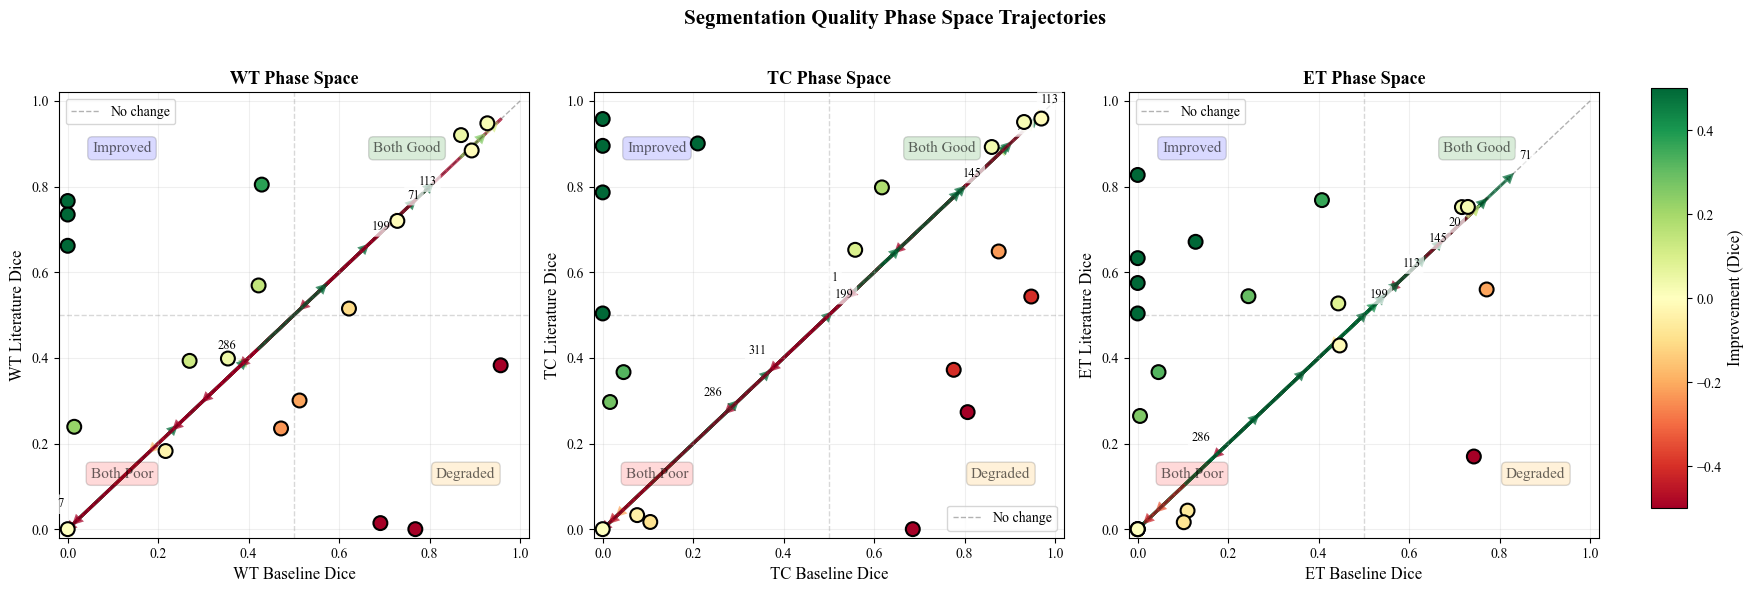

Phase space visualization saved!


In [7]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set Times New Roman font
plt.rcParams['font.family'] = 'Times New Roman'

df = pd.read_csv('MedCLIP-SAMv2/evaluation_results_literature.csv')

fig, axes = plt.subplots(1, 3, figsize=(18, 6))

regions = ['WT', 'TC', 'ET']

for ax, region in zip(axes, regions):
    baseline = df[f'{region}_Baseline'].values
    literature = df[f'{region}_Literature'].values
    improvement = df[f'{region}_Improvement'].values
    
    # Quadrant lines
    ax.axhline(0.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    ax.axvline(0.5, color='gray', linestyle='--', alpha=0.3, linewidth=1)
    ax.plot([0, 1], [0, 1], 'k--', alpha=0.3, linewidth=1, label='No change')
    
    # Quadrant labels - positioned away from data points
    ax.text(0.75, 0.88, 'Both Good', fontsize=11, alpha=0.6, ha='center', 
           bbox=dict(boxstyle='round', facecolor='green', alpha=0.15))
    ax.text(0.12, 0.12, 'Both Poor', fontsize=11, alpha=0.6, ha='center',
           bbox=dict(boxstyle='round', facecolor='red', alpha=0.15))
    ax.text(0.12, 0.88, 'Improved', fontsize=11, alpha=0.6, ha='center',
           bbox=dict(boxstyle='round', facecolor='blue', alpha=0.15))
    ax.text(0.88, 0.12, 'Degraded', fontsize=11, alpha=0.6, ha='center',
           bbox=dict(boxstyle='round', facecolor='orange', alpha=0.15))
    
    # Trajectory arrows
    for i in range(len(df)):
        color = plt.cm.RdYlGn(0.5 + improvement[i] * 5)
        ax.arrow(baseline[i], baseline[i], 
                literature[i] - baseline[i], literature[i] - baseline[i],
                head_width=0.015, head_length=0.015, fc=color, ec=color,
                linewidth=2, alpha=0.7, length_includes_head=True)
    
    # Patient points
    scatter = ax.scatter(baseline, literature, c=improvement, s=100, 
                        cmap='RdYlGn', edgecolors='black', linewidths=1.5, 
                        zorder=10, vmin=-0.5, vmax=0.5)
    
    # Annotations - only for extreme cases and positioned to avoid overlap
    for i in range(len(df)):
        if abs(improvement[i]) > 0.4:  # Only annotate very large changes
            # Offset annotation to avoid overlap
            offset_x = 0.03 if literature[i] > baseline[i] else -0.03
            offset_y = 0.03
            ax.annotate(f'{df.iloc[i]["Patient_Idx"]}', 
                       (literature[i] + offset_x, literature[i] + offset_y),
                       fontsize=9, ha='center', va='bottom',
                       bbox=dict(boxstyle='round,pad=0.3', facecolor='white', alpha=0.7, edgecolor='none'))
    
    ax.set_xlabel(f'{region} Baseline Dice', fontsize=12, family='Times New Roman')
    ax.set_ylabel(f'{region} Literature Dice', fontsize=12, family='Times New Roman')
    ax.set_title(f'{region} Phase Space', fontsize=13, fontweight='bold', family='Times New Roman')
    ax.set_xlim(-0.02, 1.02)
    ax.set_ylim(-0.02, 1.02)
    ax.grid(alpha=0.2)
    ax.legend(fontsize=10, prop={'family': 'Times New Roman'})
    
    # Set tick label font
    for label in ax.get_xticklabels() + ax.get_yticklabels():
        label.set_fontname('Times New Roman')

# Shared colorbar
fig.subplots_adjust(right=0.9)
cbar_ax = fig.add_axes([0.92, 0.15, 0.02, 0.7])
cbar = fig.colorbar(scatter, cax=cbar_ax, label='Improvement (Dice)')
cbar.ax.set_ylabel('Improvement (Dice)', fontsize=12, family='Times New Roman')
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Times New Roman')

plt.suptitle('Segmentation Quality Phase Space Trajectories', fontsize=15, fontweight='bold', y=0.98, family='Times New Roman')
plt.tight_layout(rect=[0, 0, 0.9, 0.96])
plt.savefig('phase_space_clean.png', dpi=300, bbox_inches='tight')
plt.show()

print("Phase space visualization saved!")

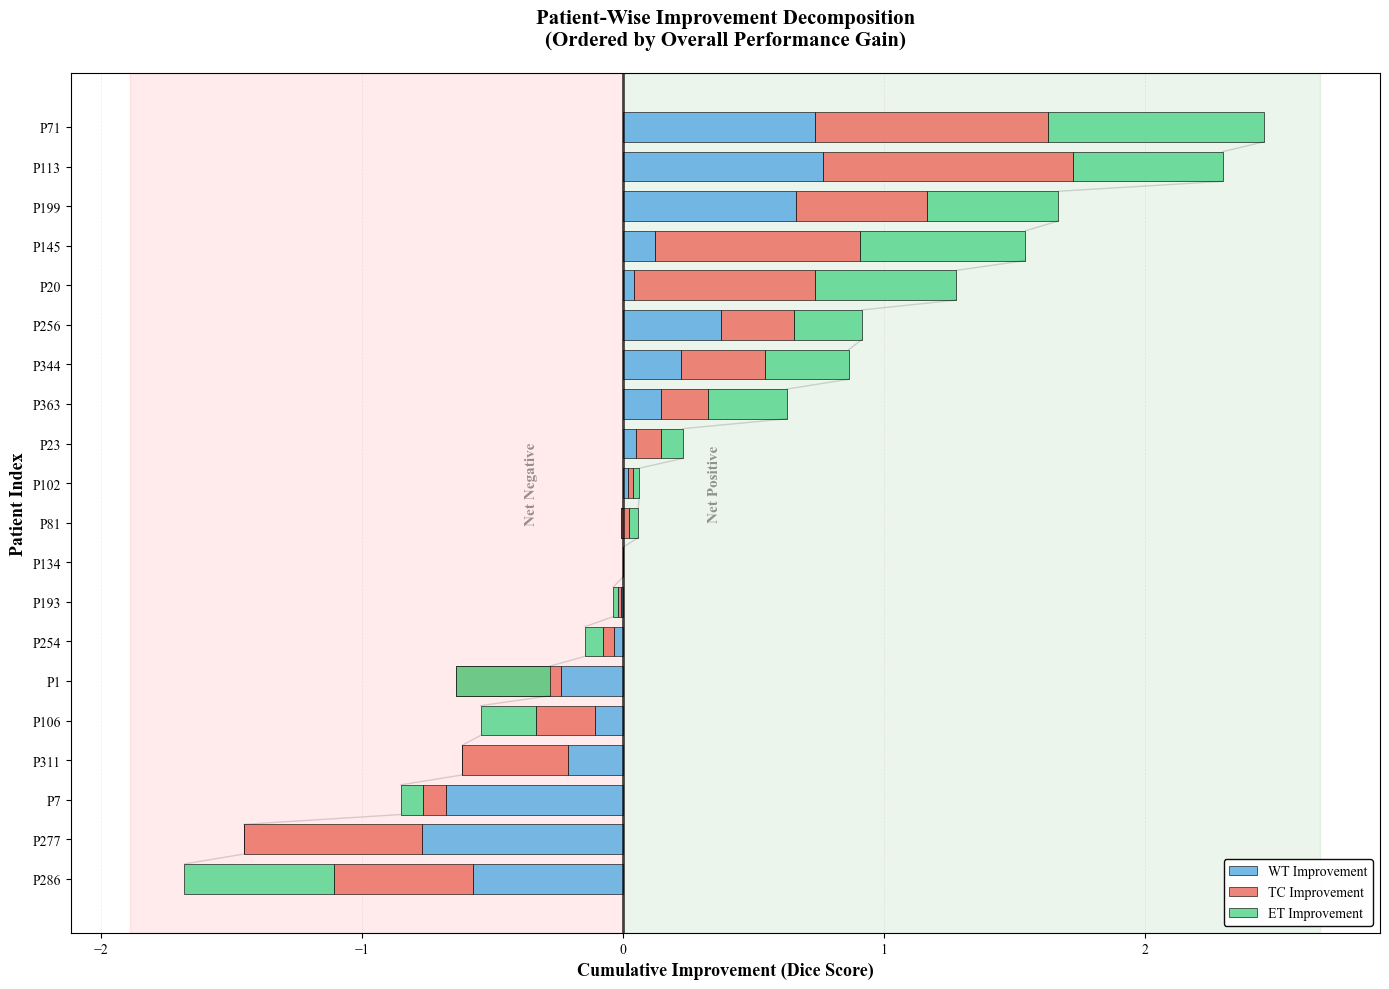

Publication-grade improvement cascade saved!


In [8]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Set Times New Roman font
plt.rcParams['font.family'] = 'Times New Roman'

df = pd.read_csv('MedCLIP-SAMv2/evaluation_results_literature.csv')

# Compute overall improvement and sort
df['Overall_Improvement'] = (df['WT_Improvement'] + df['TC_Improvement'] + df['ET_Improvement']) / 3
df_sorted = df.sort_values('Overall_Improvement', ascending=True).reset_index(drop=True)

fig, ax = plt.subplots(figsize=(14, 10))

# Prepare data
patients = df_sorted['Patient_Idx'].values
wt_imp = df_sorted['WT_Improvement'].values
tc_imp = df_sorted['TC_Improvement'].values
et_imp = df_sorted['ET_Improvement'].values

# Create waterfall bars
bar_width = 0.75
x = np.arange(len(patients))

# Stack improvements
bottom_tc = wt_imp.copy()
bottom_et = wt_imp + tc_imp

# Plot stacked bars with more professional colors
bars1 = ax.barh(x, wt_imp, bar_width, label='WT Improvement', color='#5DADE2', alpha=0.85, edgecolor='black', linewidth=0.5)
bars2 = ax.barh(x, tc_imp, bar_width, left=bottom_tc, label='TC Improvement', color='#EC7063', alpha=0.85, edgecolor='black', linewidth=0.5)
bars3 = ax.barh(x, et_imp, bar_width, left=bottom_et, label='ET Improvement', color='#58D68D', alpha=0.85, edgecolor='black', linewidth=0.5)

# Zero line (more prominent)
ax.axvline(0, color='black', linewidth=2, linestyle='-', alpha=0.7, zorder=5)

# Flowing connector lines (cascade effect)
for i in range(len(patients) - 1):
    total_current = wt_imp[i] + tc_imp[i] + et_imp[i]
    total_next = wt_imp[i+1] + tc_imp[i+1] + et_imp[i+1]
    ax.plot([total_current, total_next], [i + bar_width/2, i + 1 - bar_width/2], 
           'k-', alpha=0.15, linewidth=1, zorder=1)

# Color regions (background shading)
ax.axvspan(ax.get_xlim()[0], 0, alpha=0.08, color='red', zorder=0)
ax.axvspan(0, ax.get_xlim()[1], alpha=0.08, color='green', zorder=0)

# Add region labels
y_mid = len(patients) / 2
ax.text(-0.35, y_mid, 'Net Negative', fontsize=11, alpha=0.4, ha='center', va='center',
       rotation=90, family='Times New Roman', fontweight='bold')
ax.text(0.35, y_mid, 'Net Positive', fontsize=11, alpha=0.4, ha='center', va='center',
       rotation=90, family='Times New Roman', fontweight='bold')

# Labels
ax.set_yticks(x)
ax.set_yticklabels([f'P{p}' for p in patients], fontsize=10, family='Times New Roman')
ax.set_xlabel('Cumulative Improvement (Dice Score)', fontsize=13, family='Times New Roman', fontweight='bold')
ax.set_ylabel('Patient Index', fontsize=13, family='Times New Roman', fontweight='bold')
ax.set_title('Patient-Wise Improvement Decomposition\n(Ordered by Overall Performance Gain)', 
            fontsize=15, fontweight='bold', family='Times New Roman', pad=20)

# Legend with better positioning
ax.legend(loc='lower right', fontsize=11, framealpha=0.95, edgecolor='black', 
         prop={'family': 'Times New Roman', 'weight': 'normal'})

# Grid
ax.grid(axis='x', alpha=0.25, linestyle='--', linewidth=0.5)
ax.set_axisbelow(True)

# Set tick label font
for label in ax.get_xticklabels() + ax.get_yticklabels():
    label.set_fontname('Times New Roman')
    label.set_fontsize(10)

# Tight layout
plt.tight_layout()
plt.savefig('improvement_cascade_publication.png', dpi=300, bbox_inches='tight')
plt.show()

print("Publication-grade improvement cascade saved!")

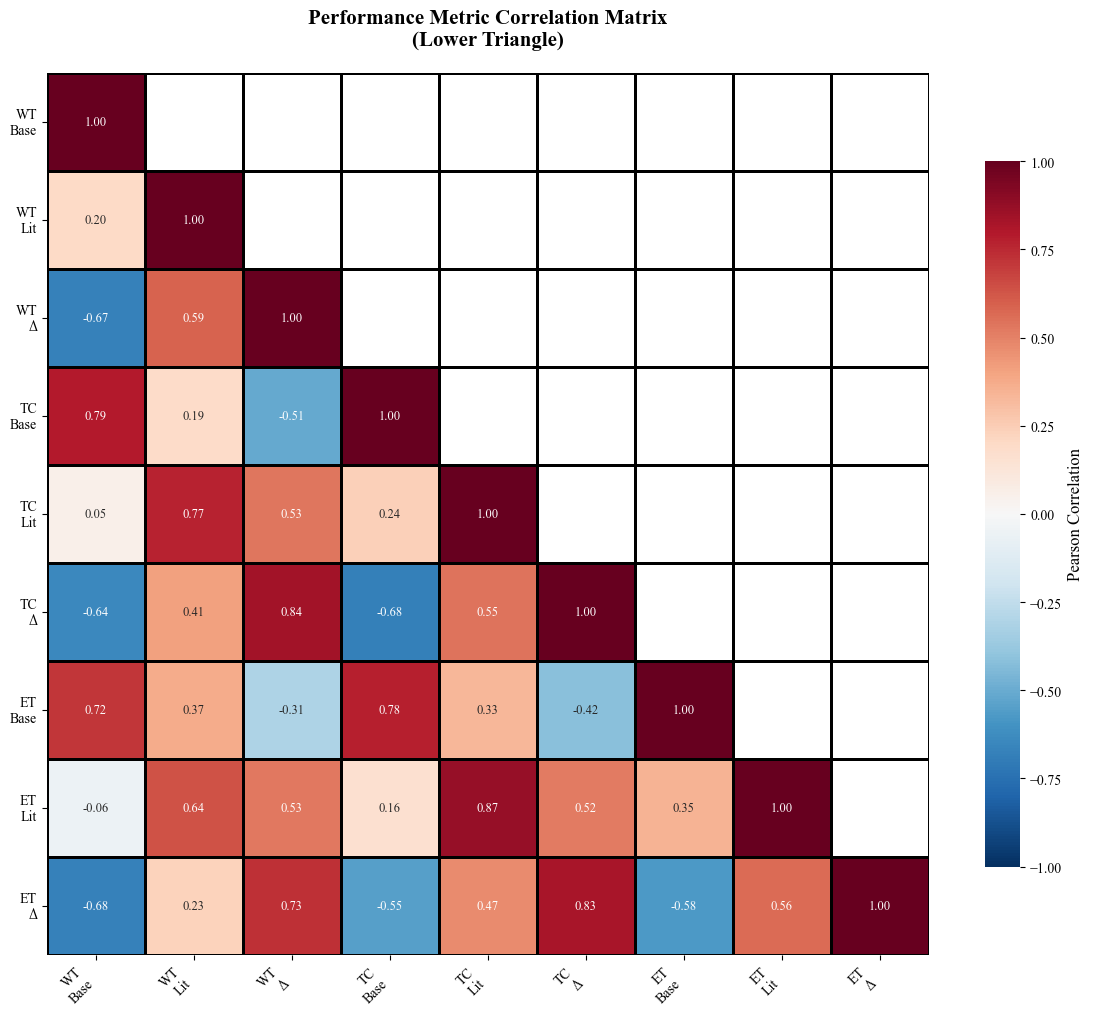

Correlation heatmap saved!


In [10]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

plt.rcParams['font.family'] = 'Times New Roman'

df = pd.read_csv('MedCLIP-SAMv2/evaluation_results_literature.csv')

# Select relevant columns
cols = ['WT_Baseline', 'WT_Literature', 'WT_Improvement',
        'TC_Baseline', 'TC_Literature', 'TC_Improvement',
        'ET_Baseline', 'ET_Literature', 'ET_Improvement']

corr_matrix = df[cols].corr()

fig, ax = plt.subplots(figsize=(12, 10))

# Create heatmap
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)  # Mask upper triangle
sns.heatmap(corr_matrix, mask=mask, annot=True, fmt='.2f', 
           cmap='RdBu_r', center=0, vmin=-1, vmax=1,
           square=True, linewidths=1, linecolor='black',
           cbar_kws={'label': 'Pearson Correlation', 'shrink': 0.8},
           annot_kws={'fontsize': 9, 'family': 'Times New Roman'},
           ax=ax)

# Labels
labels = ['WT\nBase', 'WT\nLit', 'WT\nΔ',
          'TC\nBase', 'TC\nLit', 'TC\nΔ',
          'ET\nBase', 'ET\nLit', 'ET\nΔ']

ax.set_xticklabels(labels, fontsize=10, family='Times New Roman', rotation=45, ha='right')
ax.set_yticklabels(labels, fontsize=10, family='Times New Roman', rotation=0)
ax.set_title('Performance Metric Correlation Matrix\n(Lower Triangle)', 
            fontsize=15, fontweight='bold', family='Times New Roman', pad=20)

# Colorbar font
cbar = ax.collections[0].colorbar
cbar.ax.set_ylabel('Pearson Correlation', fontsize=12, family='Times New Roman')
for label in cbar.ax.get_yticklabels():
    label.set_fontname('Times New Roman')

plt.tight_layout()
plt.savefig('correlation_heatmap.png', dpi=300, bbox_inches='tight')
plt.show()

print("Correlation heatmap saved!")

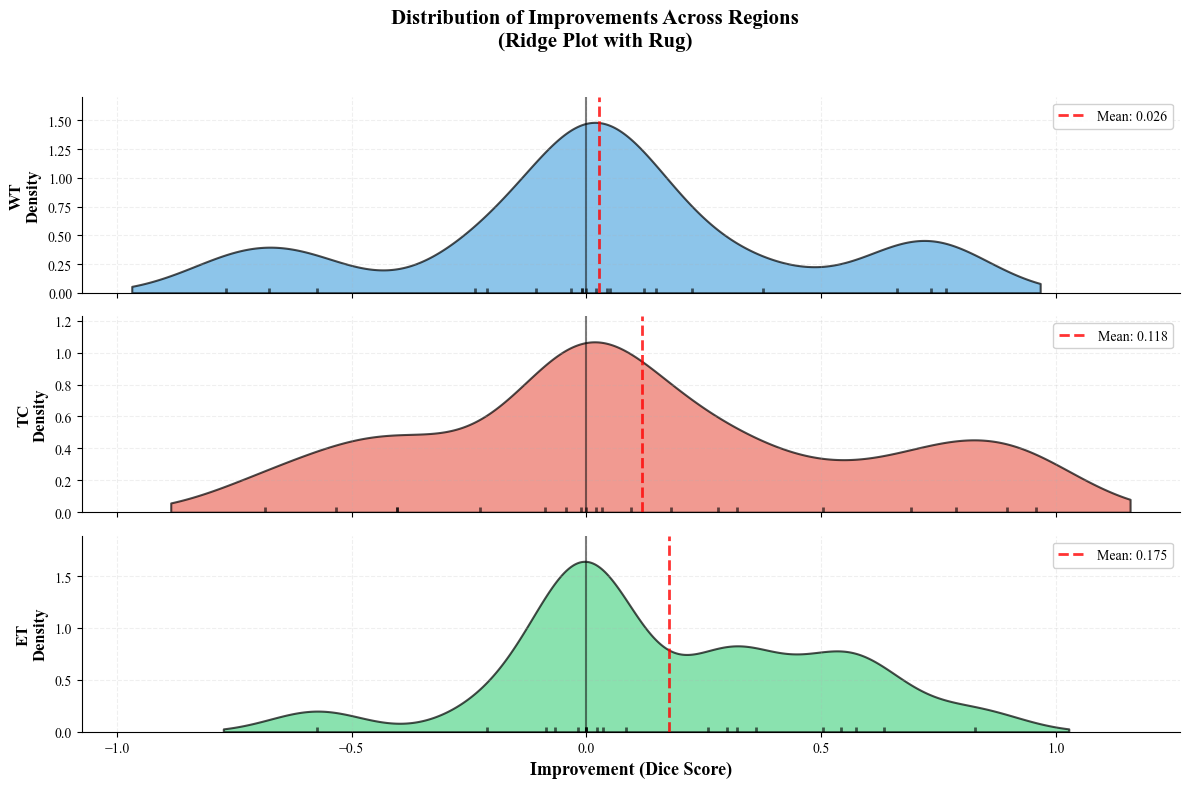

Ridge plot saved!


In [11]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from scipy import stats

plt.rcParams['font.family'] = 'Times New Roman'

df = pd.read_csv('MedCLIP-SAMv2/evaluation_results_literature.csv')

fig, axes = plt.subplots(3, 1, figsize=(12, 8), sharex=True)

regions = ['WT', 'TC', 'ET']
colors = ['#5DADE2', '#EC7063', '#58D68D']

for idx, (ax, region, color) in enumerate(zip(axes, regions, colors)):
    improvements = df[f'{region}_Improvement'].values
    
    # KDE
    kde = stats.gaussian_kde(improvements, bw_method=0.3)
    x_range = np.linspace(improvements.min() - 0.2, improvements.max() + 0.2, 500)
    density = kde(x_range)
    
    # Fill area
    ax.fill_between(x_range, 0, density, alpha=0.7, color=color, edgecolor='black', linewidth=1.5)
    
    # Individual points (rug plot)
    ax.scatter(improvements, np.zeros_like(improvements), 
              color='black', s=50, alpha=0.6, zorder=10, marker='|', linewidths=2)
    
    # Mean line
    mean_val = improvements.mean()
    ax.axvline(mean_val, color='red', linestyle='--', linewidth=2, alpha=0.8, 
              label=f'Mean: {mean_val:.3f}')
    
    # Zero line
    ax.axvline(0, color='black', linestyle='-', linewidth=1.5, alpha=0.5)
    
    # Labels
    ax.set_ylabel(f'{region}\nDensity', fontsize=12, family='Times New Roman', fontweight='bold')
    ax.set_ylim(0, density.max() * 1.15)
    ax.legend(loc='upper right', fontsize=10, framealpha=0.9, prop={'family': 'Times New Roman'})
    ax.grid(alpha=0.2, linestyle='--')
    
    # Remove top and right spines
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    
    for label in ax.get_yticklabels():
        label.set_fontname('Times New Roman')

# Bottom plot xlabel
axes[-1].set_xlabel('Improvement (Dice Score)', fontsize=13, family='Times New Roman', fontweight='bold')
for label in axes[-1].get_xticklabels():
    label.set_fontname('Times New Roman')

fig.suptitle('Distribution of Improvements Across Regions\n(Ridge Plot with Rug)', 
            fontsize=15, fontweight='bold', family='Times New Roman', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('ridge_plot.png', dpi=300, bbox_inches='tight')
plt.show()

print("Ridge plot saved!")

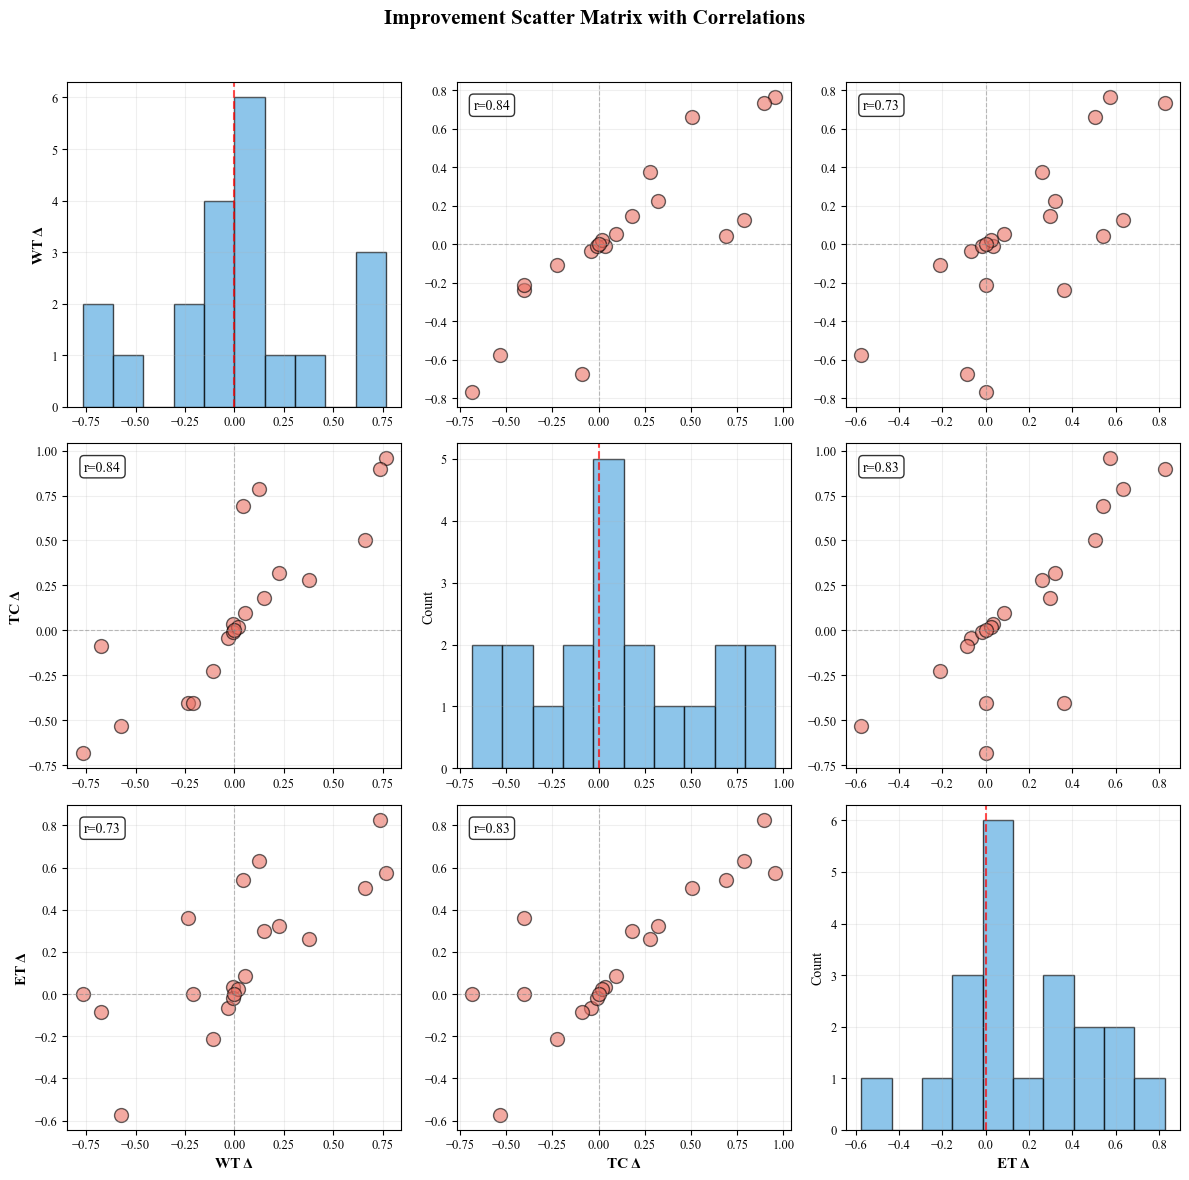

Scatter matrix saved!


In [13]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

plt.rcParams['font.family'] = 'Times New Roman'

df = pd.read_csv('MedCLIP-SAMv2/evaluation_results_literature.csv')

improvements = df[['WT_Improvement', 'TC_Improvement', 'ET_Improvement']]
labels = ['WT Δ', 'TC Δ', 'ET Δ']

fig, axes = plt.subplots(3, 3, figsize=(12, 12))

for i in range(3):
    for j in range(3):
        ax = axes[i, j]
        
        if i == j:
            # Diagonal: histogram
            ax.hist(improvements.iloc[:, i], bins=10, color='#5DADE2', 
                   alpha=0.7, edgecolor='black', linewidth=1)
            ax.axvline(0, color='red', linestyle='--', linewidth=1.5, alpha=0.7)
            ax.set_ylabel('Count', fontsize=10, family='Times New Roman')
        else:
            # Off-diagonal: scatter
            x = improvements.iloc[:, j]
            y = improvements.iloc[:, i]
            
            ax.scatter(x, y, s=100, alpha=0.6, color='#EC7063', edgecolors='black', linewidths=1)
            
            # Add correlation
            corr = np.corrcoef(x, y)[0, 1]
            ax.text(0.05, 0.95, f'r={corr:.2f}', transform=ax.transAxes,
                   fontsize=10, va='top', family='Times New Roman',
                   bbox=dict(boxstyle='round', facecolor='white', alpha=0.8))
            
            # Reference lines
            ax.axhline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
            ax.axvline(0, color='gray', linestyle='--', linewidth=0.8, alpha=0.5)
        
        # Labels
        if i == 2:
            ax.set_xlabel(labels[j], fontsize=11, family='Times New Roman', fontweight='bold')
        if j == 0:
            ax.set_ylabel(labels[i], fontsize=11, family='Times New Roman', fontweight='bold')
        
        ax.grid(alpha=0.2)
        
        for label in ax.get_xticklabels() + ax.get_yticklabels():
            label.set_fontname('Times New Roman')
            label.set_fontsize(9)

fig.suptitle('Improvement Scatter Matrix with Correlations', 
            fontsize=15, fontweight='bold', family='Times New Roman', y=0.98)

plt.tight_layout(rect=[0, 0, 1, 0.96])
plt.savefig('scatter_matrix.png', dpi=300, bbox_inches='tight')
plt.show()

print("Scatter matrix saved!")